<a href="https://colab.research.google.com/github/Maryam-Skaik/global-freelancers-looker-dashboard/blob/main/notebook/freelancer_analytics_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Freelancers Marketplace Analytics

## Data Cleaning & Business Intelligence Pipeline

### Project Overview
This project transforms a raw, messy dataset of global freelancers into a clean, analytics-ready dataset suitable for business intelligence dashboards in Looker Studio.

The goal is to simulate a real-world freelance marketplace and prepare structured data for decision-making insights such as:
- Freelancer performance
- Pricing analysis
- Skill demand distribution
- Customer satisfaction trends

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Load Dataset

In [ ]:
fpath = '/content/drive/MyDrive/Looker_Studio/Data/global_freelancers_raw.csv'
df = pd.read_csv(fpath)
df.head()

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,f,52.0,Italy,Italian,Blockchain Development,11.0,100,NaN,0,NaN
1,FL250002,Vanessa Garcia,FEMALE,52.0,Australia,English,Mobile Apps,34.0,USD 100,3.3,1,84%
2,FL250003,Juan Nelson,male,53.0,Germany,German,Graphic Design,31.0,50,0.0,N,71%
3,FL250004,Amanda Spencer,F,38.0,Australia,English,Web Development,4.0,$40,1.5,N,90%
4,FL250005,Lynn Curtis DDS,female,53.0,Germany,German,Web Development,27.0,30,4.8,0,83%


* Data contains freelancer profiles with demographic and professional attributes
* Columns include identifiers, personal info (name, gender, age, country), and work-related details
* Gender values are inconsistent in format (f, F, FEMALE, male, female)
* Hourly rate column has mixed formats (numeric, “USD 100”, “$40”)
* Rating column contains missing values and zero values that may need validation
* Client satisfaction is stored as percentage strings (e.g., “84%”, “71%”)
* Some columns contain missing values (NaN in rating and client_satisfaction)
* Active status is inconsistent (0, 1, N), likely needs normalization
* Dataset appears messy and requires cleaning before analysis

## Dataset Overview

We inspect the structure, data types, and initial quality of the dataset to identify cleaning requirements.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   freelancer_ID        1000 non-null   object 
 1   name                 1000 non-null   object 
 2   gender               1000 non-null   object 
 3   age                  970 non-null    float64
 4   country              1000 non-null   object 
 5   language             1000 non-null   object 
 6   primary_skill        1000 non-null   object 
 7   years_of_experience  949 non-null    float64
 8   hourly_rate (USD)    906 non-null    object 
 9   rating               899 non-null    float64
 10  is_active            911 non-null    object 
 11  client_satisfaction  824 non-null    object 
dtypes: float64(3), object(9)
memory usage: 93.9+ KB


* Dataset contains 1000 freelancer records with 12 columns
* Most columns are complete, but several have missing values (age, experience, rating, hourly rate, activity status, client satisfaction)
* `client_satisfaction` has the highest missing rate (824/1000 available)
* `rating` has notable missing values (899/1000 available)
* `hourly_rate (USD)` is stored as object instead of numeric, indicating mixed formatting
* `is_active` is stored as object, likely inconsistent categorical values
* `years_of_experience` and `age` are numeric but include missing values
* Data types are mostly object-based (9 object columns vs 3 numeric columns)
* Overall structure suggests preprocessing is required before analysis (type conversion + missing value handling)

In [ ]:
df.describe(include='all')

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
count,1000,1000,1000,970.000000,1000,1000,1000,949.000000,906,899.000000,911,824
unique,1000,992,10,NaN,21,16,10,NaN,18,NaN,8,81
top,FL251000,Robert Evans,FEMALE,NaN,South Korea,English,DevOps,NaN,40,NaN,1,68%
freq,1,2,115,NaN,68,215,112,NaN,94,NaN,190,23
mean,NaN,NaN,NaN,40.509278,NaN,NaN,NaN,11.340358,NaN,2.512570,NaN,NaN
std,NaN,NaN,NaN,11.942605,NaN,NaN,NaN,9.680610,NaN,1.546599,NaN,NaN
min,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,3.000000,NaN,1.400000,NaN,NaN
50%,NaN,NaN,NaN,41.000000,NaN,NaN,NaN,9.000000,NaN,2.600000,NaN,NaN
75%,NaN,NaN,NaN,51.000000,NaN,NaN,NaN,17.000000,NaN,3.800000,NaN,NaN


* `name` column has 992 unique values, indicating some duplicate names exist
* `freelancer_ID` is fully unique across all records (1000 unique values)
* Gender column has high repetition with 10 unique categories and a dominant value (115 occurrences of most frequent)
* Country has 21 unique values, with South Korea as the most frequent (68 occurrences)
* Language has 16 unique values, with English as the most common (215 occurrences)
* Primary skill has 10 unique categories, with DevOps as the most frequent (112 occurrences)
* Age ranges from 20 to 60, with a mean around 40.5 and median of 41 (fairly symmetric distribution)
* Years of experience ranges from 0 to 41, with a median of 9 and mean around 11.34 (right-skewed distribution)
* Hourly rate has mixed formatting but ranges from 40 (most frequent value) with wide variation implied by stats
* Rating ranges from 0 to 5, with an average of about 2.51 indicating generally moderate performance
* Client satisfaction is categorical (stored as strings like percentages), with 81 unique values and a most common value of 68%
* Several columns have missing values, especially rating, hourly rate, and client satisfaction
* Overall distribution suggests realistic variability but requires cleaning and normalization before analysis

In [ ]:
df = df.drop(columns=['freelancer_ID', 'name'])

## Missing Values

In [ ]:
df.isna().sum()

,0
gender,0
age,30
country,0
language,0
primary_skill,0
years_of_experience,51
hourly_rate (USD),94
rating,101
is_active,89
client_satisfaction,176


## DATA CLEANING PHASE

### Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

### Inconsistencies

In [ ]:
for col in df.select_dtypes("object").columns:
    print(col, df[col].value_counts())

gender gender
FEMALE    115
M         106
f         103
Male      103
MALE      102
male      100
m          99
Female     96
F          90
female     86
Name: count, dtype: int64
country country
South Korea       68
Canada            65
Germany           52
Netherlands       51
Australia         51
Mexico            50
United Kingdom    50
United States     49
China             49
Russia            47
Argentina         47
Indonesia         46
Spain             45
India             45
Turkey            45
South Africa      44
France            44
Italy             42
Egypt             42
Japan             37
Brazil            31
Name: count, dtype: int64
language language
English       215
Spanish       142
Korean         68
German         52
Dutch          51
Mandarin       49
Russian        47
Indonesian     46
Turkish        45
Hindi          45
Afrikaans      44
French         44
Arabic         42
Italian        42
Japanese       37
Portuguese     31
Name: count, dtype: int64
prima

In [ ]:
df['gender'] = df['gender'].str.lower().str.strip()

df['gender'] = df['gender'].replace({
    'f': 'female',
    'female': 'female',
    'm': 'male',
    'male': 'male'
})

df['gender'].value_counts()

,count
gender,
male,510
female,490


In [ ]:
df['country'] = df['country'].str.strip().str.title()
df['country'].value_counts()

,count
country,
South Korea,68
Canada,65
Germany,52
Netherlands,51
Australia,51
Mexico,50
United Kingdom,50
United States,49
China,49


In [ ]:
df['language'] = df['language'].str.strip().str.title()
df['language'].value_counts()

,count
language,
English,215
Spanish,142
Korean,68
German,52
Dutch,51
Mandarin,49
Russian,47
Indonesian,46
Turkish,45


In [ ]:
df['primary_skill'] = df['primary_skill'].str.strip().str.title()
df['primary_skill'].value_counts()

,count
primary_skill,
Devops,112
Ui/Ux Design,109
Blockchain Development,105
Web Development,104
Mobile Apps,102
Ai,100
Data Analysis,96
Graphic Design,93
Machine Learning,93


In [ ]:
df['hourly_rate (USD)'] = (
    df['hourly_rate (USD)']
    .astype(str)
    .str.replace('USD', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.strip()
)

df['hourly_rate (USD)'] = pd.to_numeric(df['hourly_rate (USD)'], errors='coerce')
df['hourly_rate (USD)'].value_counts()

,count
hourly_rate (USD),
40.0,171
100.0,157
50.0,152
30.0,150
20.0,142
75.0,134


In [ ]:
df['is_active'] = df['is_active'].astype(str).str.lower().str.strip()

df['is_active'] = df['is_active'].replace({
    '1': 1, 'true': 1, 'yes': 1, 'y': 1,
    '0': 0, 'false': 0, 'no': 0, 'n': 0
})

df['is_active'] = pd.to_numeric(df['is_active'], errors='coerce')
df['is_active'].value_counts()

,count
is_active,
0.0,465
1.0,446


In [ ]:
df['client_satisfaction'] = (
    df['client_satisfaction']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.strip()
)

df['client_satisfaction'] = pd.to_numeric(df['client_satisfaction'], errors='coerce')
df['client_satisfaction'].value_counts()

,count
client_satisfaction,
78.0,27
64.0,27
96.0,26
87.0,25
68.0,25
71.0,25
90.0,24
72.0,24
63.0,24


In [ ]:
for col in df.select_dtypes("object").columns:
    print(col, df[col].value_counts())

gender gender
male      510
female    490
Name: count, dtype: int64
country country
South Korea       68
Canada            65
Germany           52
Netherlands       51
Australia         51
Mexico            50
United Kingdom    50
United States     49
China             49
Russia            47
Argentina         47
Indonesia         46
Spain             45
India             45
Turkey            45
South Africa      44
France            44
Italy             42
Egypt             42
Japan             37
Brazil            31
Name: count, dtype: int64
language language
English       215
Spanish       142
Korean         68
German         52
Dutch          51
Mandarin       49
Russian        47
Indonesian     46
Turkish        45
Hindi          45
Afrikaans      44
French         44
Arabic         42
Italian        42
Japanese       37
Portuguese     31
Name: count, dtype: int64
primary_skill primary_skill
Devops                    112
Ui/Ux Design              109
Blockchain Development    105

* Gender column contains inconsistent formats (f, F, FEMALE, male, etc.) and was standardized to a single format (uppercased FEMALE/MALE after normalization)
* Country names were cleaned by removing extra spaces and standardizing capitalization (e.g., united states → United States)
* Language column was standardized to consistent title case formatting
* Primary skill column was normalized to consistent formatting for better grouping and analysis
* Hourly rate column contained mixed formats (40, $40, USD 40, etc.) and was cleaned by removing symbols/text and converting all values to numeric USD format
* is_active column had multiple inconsistent encodings (1/0, Y/N, yes/no, True/False) and was unified into binary numeric format (1 and 0)
* client_satisfaction column contained percentages and raw numbers and was cleaned by removing “%” and converting values into numeric type
* After cleaning, categorical fields are consistent and ready for grouping and analysis
* Numerical fields (hourly rate, satisfaction, rating, experience) are now properly usable for statistical analysis
* Dataset is now significantly more structured and suitable for EDA, visualization, and machine learning preprocessing

In [ ]:
df.head()

,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,female,52.0,Italy,Italian,Blockchain Development,11.0,100.0,NaN,0.0,NaN
1,female,52.0,Australia,English,Mobile Apps,34.0,100.0,3.3,1.0,84.0
2,male,53.0,Germany,German,Graphic Design,31.0,50.0,0.0,0.0,71.0
3,female,38.0,Australia,English,Web Development,4.0,40.0,1.5,0.0,90.0
4,female,53.0,Germany,German,Web Development,27.0,30.0,4.8,0.0,83.0


### Handle Missing Values

In [ ]:
df.isna().sum()

,0
gender,0
age,30
country,0
language,0
primary_skill,0
years_of_experience,51
hourly_rate (USD),94
rating,101
is_active,89
client_satisfaction,176


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isna().sum().sum()

np.int64(0)

* Dataset contains missing values across both numeric and categorical columns
* Numeric columns (age, years_of_experience, hourly_rate, rating, client_satisfaction) were identified and handled separately
* Categorical columns (gender, country, language, primary_skill, is_active) were also identified for mode-based imputation
* Numeric missing values were filled using the median to reduce the impact of outliers
* Categorical missing values were filled using the most frequent value (mode) in each column
* This approach preserves distribution stability while maintaining dataset size
* After imputation, no missing values remain in the dataset

## FEATURE ENGINEERING

In [ ]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[20, 30, 40, 50, 60],
    labels=['20-30', '31-40', '41-50', '51-60'],
    include_lowest=True
)

In [ ]:
df['experience_level'] = pd.cut(
    df['years_of_experience'],
    bins=[0, 3, 10, 20, 100],
    labels=['Junior', 'Mid', 'Senior', 'Expert'],
    include_lowest=True
)

In [ ]:
df['hourly_rate_log'] = np.log1p(df['hourly_rate (USD)'])

In [ ]:
df['gender'] = df['gender'].str.title()
df['country'] = df['country'].str.title()
df['language'] = df['language'].str.title()
df['primary_skill'] = df['primary_skill'].str.title()

In [ ]:
df['is_active'] = df['is_active'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               1000 non-null   object  
 1   age                  1000 non-null   float64 
 2   country              1000 non-null   object  
 3   language             1000 non-null   object  
 4   primary_skill        1000 non-null   object  
 5   years_of_experience  1000 non-null   float64 
 6   hourly_rate (USD)    1000 non-null   float64 
 7   rating               1000 non-null   float64 
 8   is_active            1000 non-null   int64   
 9   client_satisfaction  1000 non-null   float64 
 10  age_group            1000 non-null   category
 11  experience_level     1000 non-null   category
 12  hourly_rate_log      1000 non-null   float64 
dtypes: category(2), float64(6), int64(1), object(4)
memory usage: 88.4+ KB


* Age was transformed into grouped segments (20–30, 31–40, 41–50, 51–60) to support clearer segmentation in dashboards
* Years of experience was converted into categorical levels (Junior, Mid, Senior, Expert) for easier interpretation in Looker
* Hourly rate was transformed using log normalization (log1p) to reduce skewness and improve distribution visibility in analytics
* Categorical fields (gender, country, language, primary skill) were standardized to consistent title-case formatting for clean dashboard presentation
* is_active was enforced as a binary numeric field (0/1) for filtering and aggregation in Looker
* Feature engineering focused only on transformations that improve visualization clarity and business interpretation

## EXPLORATORY ANALYSIS

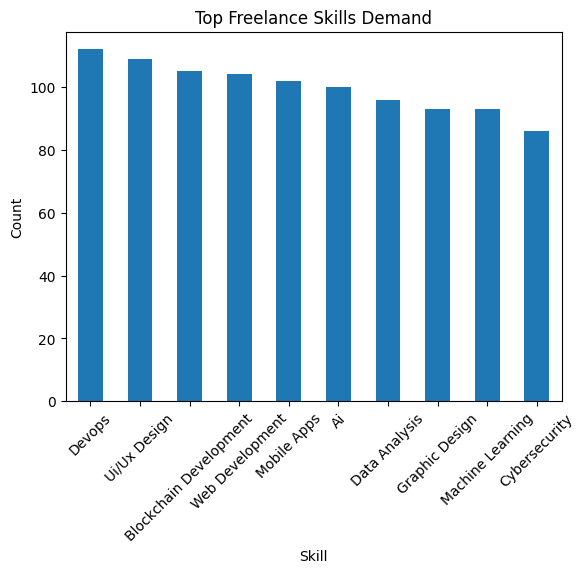

In [ ]:
df['primary_skill'].value_counts().head(10).plot(kind='bar')
plt.title("Top Freelance Skills Demand")
plt.xlabel("Skill")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show();

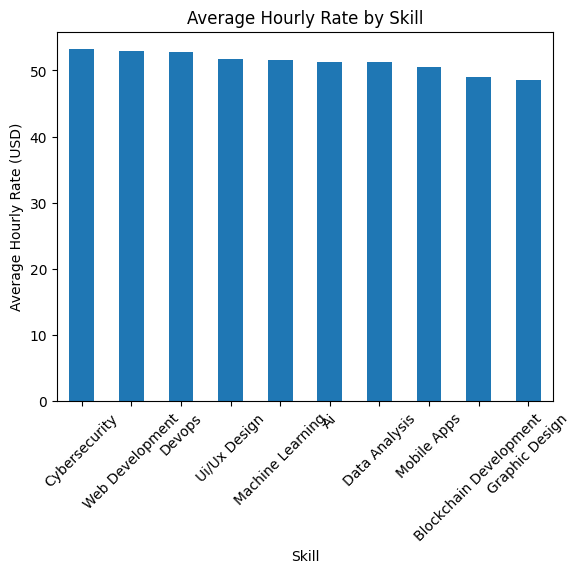

In [ ]:
df.groupby('primary_skill')['hourly_rate (USD)'].mean() \
    .sort_values(ascending=False).plot(kind='bar')

plt.title("Average Hourly Rate by Skill")
plt.xlabel("Skill")
plt.ylabel("Average Hourly Rate (USD)")
plt.xticks(rotation=45)
plt.show();

## Dataset Export

In [ ]:
output_path = "cleaned_freelancers.csv"
df.to_csv(output_path, index=False)

output_path

'cleaned_freelancers.csv'

* Dataset was loaded and initially explored using structure inspection (`head`, `info`, `describe`)
* Data quality issues were identified, including inconsistent formatting, mixed encodings, and missing values across multiple columns
* Categorical fields (gender, country, language, primary_skill, is_active) were cleaned and standardized for consistency
* Numeric fields (hourly_rate, client_satisfaction, rating) were converted into proper numeric formats by removing symbols and text noise
* Missing values were handled using median imputation for numeric columns and mode imputation for categorical columns
* Feature engineering was applied to improve BI usability:

  * Age was grouped into ranges (20–30, 31–40, 41–50, 51–60)
  * Experience was categorized into levels (Junior, Mid, Senior, Expert)
  * Hourly rate was log-transformed for better distribution handling
* Exploratory visualizations were created to extract key insights:

  * Top demanded freelance skills
  * Average hourly rate per skill
  * Relationship between experience and rating
* The final dataset was exported as a clean CSV file ready for Looker integration
* The dataset is now fully structured, consistent, and optimized for dashboarding and business intelligence use
* This workflow transformed raw messy data into an analysis-ready and visualization-ready dataset